# FX Spot, Volatility, and FX Option Pricing

This notebook is a beginner-friendly guide to foreign exchange pricing. No prior quant finance experience is required — every concept is explained from the ground up with plain language, formulas, and charts.

## What is FX?

**FX** stands for **foreign exchange** — the global market where one currency is bought or sold for another. With over $7 trillion traded every day, it is the largest financial market in the world.

An **FX rate** is simply the price of one currency expressed in another. For example:
- **EUR/USD = 1.1050** means 1 euro costs 1.1050 US dollars
- If you want to buy €100,000, you need to pay $110,500

### How to read an FX currency pair

Every FX rate has two parts:

| Term | Meaning | Example: EUR/USD |
|---|---|---|
| **Base currency** | The currency being bought or sold | EUR |
| **Quote currency** | The currency used to pay | USD |
| **Spot rate** | Today's exchange rate for immediate delivery | 1.1050 |
| **Pip** | Smallest standard price increment (usually 0.0001) | 1.1050 → 1.1051 = 1 pip |

If EUR/USD rises from 1.1050 to 1.1150, the euro has **strengthened** — it now buys more dollars. If it falls, the euro has **weakened**.

### Who uses FX pricing?
- **Corporate treasurers**: convert revenues or pay suppliers in foreign currencies
- **Importers and exporters**: hedge the risk that exchange rate moves shrink their margins
- **Banks**: quote prices and hedge FX options for clients
- **Investors**: manage currency risk in international equity or bond portfolios
- **Risk managers**: measure how much money a portfolio can lose from FX moves

## What this notebook covers

| Section | Topic |
|---|---|
| 1 | FX spot and forward pricing — why rates differ for future dates |
| 2 | Volatility — measuring how much FX rates move |
| 3 | FX options — the right to exchange at a fixed rate (calls and puts) |
| 4 | SABR smile model — handling different volatilities at different strikes |
| 5 | Practical use cases — real scenarios for importers, exporters, traders |
| 6 | Value at Risk — estimating how much you could lose |

## Suggested reading path
- **New to FX?** Read every section in order.
- **Know spot pricing?** Jump to Section 3 for options.
- **Know Garman-Kohlhagen?** Go straight to Section 4 for SABR smile.

## Key convention used throughout
- EUR is the base currency (what is being bought/sold)
- USD is the quote/domestic currency (what is being paid)
- All option premiums are expressed in USD per 1 EUR of notional

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
RNG = np.random.default_rng(7)

## 1. FX Spot and Forward Pricing

### 1.1 What is the spot rate?
The **spot rate** is the exchange rate for currency delivery today (technically 2 business days, the standard settlement). When you see EUR/USD = 1.1050 on a screen, that is the spot rate.

Spot rates change constantly because supply and demand for currencies shifts with:
- Trade flows (importers buying foreign currency)
- Investment flows (investors moving money across borders)
- Central bank policy expectations
- Risk sentiment

### 1.2 What is a forward rate?
A **forward rate** is the agreed exchange rate for currency delivery at a future date — for example, in 3 months or 1 year. Forwards are used to lock in a rate today for a transaction that will happen later.

**Why would the forward rate differ from the spot rate?**

Imagine two strategies for converting EUR to USD in 1 year:
1. Convert USD to EUR now at spot, invest the EUR at the euro interest rate for 1 year
2. Keep the USD, invest at the USD interest rate for 1 year, then convert

For no free-lunch arbitrage to exist, both strategies must give the same result. This forces the forward to depend on both interest rates.

### 1.3 Covered Interest Parity (CIP)

The **Covered Interest Parity** formula links spot rate, forward rate, and both interest rates:

$$F_{0,T} = S_0 \cdot e^{(r_d - r_f) \cdot T}$$

where:
- $S_0$ = spot FX rate today
- $F_{0,T}$ = forward FX rate for delivery at time $T$
- $r_d$ = domestic (USD) continuously compounded interest rate
- $r_f$ = foreign (EUR) continuously compounded interest rate
- $T$ = time in years

**Plain-language rule:**
- If USD rates are **higher** than EUR rates ($r_d > r_f$): the forward is **above** spot (USD costs more in the future — EUR strengthens forward)
- If USD rates are **lower** than EUR rates ($r_d < r_f$): the forward is **below** spot

### 1.4 Forward points
**Forward points** are the difference between the forward rate and the spot rate, scaled by 10,000:

$$\text{Forward points} = (F_{0,T} - S_0) \times 10{,}000$$

Forward points are the standard quoting unit in FX forward markets. A positive value means the forward is higher than spot (the base currency trades at a **premium** in the forward market).

### 1.5 Practical example
- A US importer must pay €10 million in 9 months
- Risk: EUR/USD rises and the USD payment becomes much larger
- Solution: buy a EUR/USD forward at the 9-month forward rate today
- Result: the cost in USD is locked in regardless of where spot moves

> **Important**: the forward rate is **not a forecast** of where spot will be in the future. It is purely a no-arbitrage price derived from spot and interest rates.

In [2]:
def fx_forward_rate(spot: float, domestic_rate: float, foreign_rate: float, maturity: float) -> float:
    return float(spot * math.exp((domestic_rate - foreign_rate) * maturity))


def garman_kohlhagen_price(
    spot: float,
    strike: float,
    maturity: float,
    domestic_rate: float,
    foreign_rate: float,
    volatility: float,
    option_type: str = "call",
) -> float:
    if maturity <= 0:
        intrinsic = max(spot - strike, 0.0) if option_type == "call" else max(strike - spot, 0.0)
        return float(intrinsic)

    sigma_sqrt_t = volatility * math.sqrt(maturity)
    d1 = (math.log(spot / strike) + (domestic_rate - foreign_rate + 0.5 * volatility ** 2) * maturity) / sigma_sqrt_t
    d2 = d1 - sigma_sqrt_t

    if option_type == "call":
        price = spot * math.exp(-foreign_rate * maturity) * norm.cdf(d1) - strike * math.exp(-domestic_rate * maturity) * norm.cdf(d2)
    else:
        price = strike * math.exp(-domestic_rate * maturity) * norm.cdf(-d2) - spot * math.exp(-foreign_rate * maturity) * norm.cdf(-d1)
    return float(price)


def garman_kohlhagen_delta(
    spot: float,
    strike: float,
    maturity: float,
    domestic_rate: float,
    foreign_rate: float,
    volatility: float,
    option_type: str = "call",
) -> float:
    sigma_sqrt_t = volatility * math.sqrt(maturity)
    d1 = (math.log(spot / strike) + (domestic_rate - foreign_rate + 0.5 * volatility ** 2) * maturity) / sigma_sqrt_t
    forward_factor = math.exp(-foreign_rate * maturity)
    return float(forward_factor * norm.cdf(d1) if option_type == "call" else forward_factor * (norm.cdf(d1) - 1))


def simulate_fx_path(
    spot: float,
    domestic_rate: float,
    foreign_rate: float,
    volatility: float,
    maturity: float,
    steps: int,
    rng: np.random.Generator,
) -> pd.DataFrame:
    dt = maturity / steps
    shocks = rng.normal(0.0, 1.0, size=steps)
    times = np.linspace(0.0, maturity, steps + 1)
    path = np.empty(steps + 1)
    path[0] = spot

    drift = (domestic_rate - foreign_rate - 0.5 * volatility ** 2) * dt
    diffusion = volatility * math.sqrt(dt)

    for step in range(1, steps + 1):
        path[step] = path[step - 1] * math.exp(drift + diffusion * shocks[step - 1])

    return pd.DataFrame({"time_years": times, "spot": path})


def annualized_realized_volatility(path: pd.Series, steps_per_year: int) -> float:
    log_returns = np.log(path / path.shift(1)).dropna()
    return float(log_returns.std(ddof=1) * math.sqrt(steps_per_year))

In [3]:
spot = 1.1050
domestic_rate = 0.048
foreign_rate = 0.027
maturities = np.array([1/12, 0.25, 0.5, 1.0, 2.0])
forward_table = pd.DataFrame(
    {
        "maturity_years": maturities,
        "spot": spot,
        "domestic_rate": domestic_rate,
        "foreign_rate": foreign_rate,
        "forward_rate": [fx_forward_rate(spot, domestic_rate, foreign_rate, maturity) for maturity in maturities],
    }
)
forward_table["forward_points"] = 10_000 * (forward_table["forward_rate"] - forward_table["spot"])
forward_table

,maturity_years,spot,domestic_rate,foreign_rate,forward_rate,forward_points
0,0.083333,1.105000,0.048000,0.027000,1.106935,19.354430
1,0.250000,1.105000,0.048000,0.027000,1.110817,58.165050
2,0.500000,1.105000,0.048000,0.027000,1.116664,116.636269
3,1.000000,1.105000,0.048000,0.027000,1.128450,234.503671
4,2.000000,1.105000,0.048000,0.027000,1.152398,473.983990


### How to read the forward rate table

The table shows the EUR/USD forward rate for five different delivery dates. Here is what each column means:

| Column | What it tells you |
|---|---|
| `maturity_years` | How far in the future the FX exchange will happen |
| `spot` | Today's spot rate (same for all rows — it is the starting point) |
| `domestic_rate` | USD interest rate used in the CIP formula |
| `foreign_rate` | EUR interest rate used in the CIP formula |
| `forward_rate` | The fair exchange rate locked in today for that future delivery date |
| `forward_points` | (Forward − Spot) × 10,000 — the standard quoting unit in FX forward markets |

**Reading the numbers:**
- `forward_rate > spot`: USD rates are higher than EUR rates, so the USD is at a forward **premium** (each EUR buys more USD in the future)
- Positive `forward_points`: same meaning — USD trades expensive for future delivery
- The further out you go, the larger the forward point differential because the rate difference compounds over a longer period

**Real-world use:** a corporate treasurer locking a 1-year forward would agree to exchange at the `forward_rate` in the 1-year row, not at today's spot.

## 2. FX Volatility

### 2.1 What is volatility?

**Volatility** measures how much an exchange rate moves over time. Think of it as the "speed" of rate changes:
- **High volatility**: large, unpredictable swings. EUR/USD might move 2–3% in a day.
- **Low volatility**: small, calm moves. EUR/USD moves only 0.2% in a day.

Mathematically, volatility is the **annualised standard deviation of daily log returns**. For EUR/USD, it is typically expressed as a percentage per year (e.g., 11.5% per year).

### 2.2 Three types of volatility

| Type | Definition | How it is calculated | When you use it |
|---|---|---|---|
| **Realized volatility** | Volatility actually observed from past prices | Measure daily returns, compute std dev, annualise | Assessing how volatile it has been |
| **Historical volatility** | Same as realized, usually over a fixed window (e.g., 30-day or 90-day) | Rolling window calculation | Comparing current level to history |
| **Implied volatility** | Volatility backed out from an option's market price | Solve Garman-Kohlhagen formula backwards | The market's expectation of future volatility |

### 2.3 Why volatility is crucial for options

For a buyer of an FX option:
- You pay an upfront **premium** to protect against adverse exchange rate moves
- More volatility = larger possible moves = more valuable protection = **higher premium**

Both call and put premiums increase with volatility. This is one of the most important rules in options:
> **Higher volatility always makes options more expensive** (for both calls and puts).

### 2.4 Volatility smile and skew

In a perfect theoretical world, implied volatility would be the same for all strikes. In practice, it is not:
- **Smile**: implied vol is higher for far out-of-the-money options than for at-the-money
- **Skew**: implied vol is higher on one side (usually the downside in FX) than the other

This happens because market participants pay extra for "tail risk" protection — the fear of extreme moves.

### 2.5 FX volatility quoting conventions
FX option traders typically quote volatility in terms of:
- **ATM volatility**: vol at the at-the-money strike
- **Risk reversal (RR)**: difference in vol between a 25-delta call and a 25-delta put — measures skew
- **Butterfly (BF)**: extra vol for out-of-the-money options versus ATM — measures the smile curvature

This notebook uses strike-based examples for clarity, but the underlying maths is identical.

In [4]:
volatility = 0.115
fx_path = simulate_fx_path(
    spot=spot,
    domestic_rate=domestic_rate,
    foreign_rate=foreign_rate,
    volatility=volatility,
    maturity=1.0,
    steps=252,
    rng=RNG,
)
realized_vol = annualized_realized_volatility(fx_path["spot"], steps_per_year=252)

vol_surface_df = pd.DataFrame(
    {
        "maturity_years": [0.25, 0.5, 1.0, 2.0],
        "atm_implied_vol": [0.104, 0.109, 0.115, 0.121],
    }
)

vol_summary_df = pd.DataFrame(
    {
        "metric": ["Input annual volatility", "Simulated realized volatility", "1Y ATM implied volatility"],
        "value": [volatility, realized_vol, vol_surface_df.loc[vol_surface_df["maturity_years"] == 1.0, "atm_implied_vol"].iloc[0]],
    }
)
vol_summary_df

,metric,value
0,Input annual volatility,0.115000
1,Simulated realized volatility,0.106076
2,1Y ATM implied volatility,0.115000


### How to read the volatility summary table

| Row | What it means |
|---|---|
| Input annual volatility | The vol we assumed when simulating the FX path (11.5%) |
| Simulated realized volatility | The vol actually measured from the simulated price path — usually close to the input but not identical due to random variation |
| 1Y ATM implied volatility | The market-quoted vol for a 1-year at-the-money option on this pair |

**Key point:** the simulated realized vol will rarely equal exactly 11.5% even though that was the input. This is normal — just as a fair coin can come up heads 7 times out of 10 in a short run. Over many more observations, the realized vol would converge towards 11.5%.

**Implied vs realized:** if implied vol (11.5%) is persistently higher than realized vol (say 9%), it means the options market is charging a risk premium — buyers are paying more than the statistical cost because they value the certainty of the hedge.

## 3. FX Options

### 3.1 What is an option?

An **FX option** gives you the **right, but not the obligation**, to exchange currencies at a fixed rate (the *strike*) on or before a future date (the *expiry*). You pay an upfront fee called the **premium** to get this right.

**Option vs Forward:**
| Feature | Forward | Option |
|---|---|---|
| Cost | Free upfront (settled at maturity) | Premium paid upfront |
| Obligation? | Yes — you must exchange at the forward rate | No — you can walk away if the market is better |
| Upside potential | Locked in (no benefit if market moves in your favour) | Unlimited — you only use the option if it helps you |
| Downside protection | Yes | Yes |

The key insight: **options let you hedge downside risk while keeping the upside**. This flexibility costs the premium.

### 3.2 Call options

A **call option on EUR/USD** gives the right to **buy EUR** (pay USD) at the strike rate.

- **If spot at expiry > strike**: you use the option. Payoff = spot − strike (you buy EUR cheap)
- **If spot at expiry ≤ strike**: you let the option expire. Payoff = 0 (you buy EUR at market instead)

**Example:** You buy a 1Y EUR call with strike 1.10 and pay a premium of $0.030 per EUR. At expiry:
- If EUR/USD = 1.20: you exercise → gain 0.10, net payoff = 0.10 − 0.030 = **+$0.07 per EUR**
- If EUR/USD = 1.05: option expires worthless, total loss = **−$0.030 per EUR** (just the premium)

### 3.3 Put options

A **put option on EUR/USD** gives the right to **sell EUR** (receive USD) at the strike rate.

- **If spot at expiry < strike**: you use the option. Payoff = strike − spot (you sell EUR at a good rate)
- **If spot at expiry ≥ strike**: you let it expire.

**Example:** A Eurozone exporter selling USD income buys a EUR put at strike 1.10. If EUR/USD falls to 1.00, the put pays out 0.10 per EUR, protecting the exporter's margin.

### 3.4 Option moneyness

| Term | Meaning | Call example (K=1.10, spot=1.1050) |
|---|---|---|
| **In-the-money (ITM)** | Would have positive payoff if exercised right now | ✅ Spot > strike: 1.1050 > 1.10 |
| **At-the-money (ATM)** | Strike ≈ spot | Spot ≈ strike |
| **Out-of-the-money (OTM)** | Would have zero payoff if exercised right now | ❌ Spot < strike |

### 3.5 Garman-Kohlhagen model

The standard model for European FX options extends Black-Scholes by treating the foreign interest rate like a continuous yield on the underlying currency.

**Call price:**
$$C = S_0 e^{-r_f T} N(d_1) - K e^{-r_d T} N(d_2)$$

**Put price:**
$$P = K e^{-r_d T} N(-d_2) - S_0 e^{-r_f T} N(-d_1)$$

where:
$$d_1 = \frac{\ln(S_0/K) + (r_d - r_f + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

**What each input does:**
- $S_0$ (spot): higher spot → call cheaper to deliver → call premium rises
- $K$ (strike): higher strike → call needs larger move to pay off → call premium falls
- $T$ (maturity): more time → more chance of favorable moves → premium rises
- $\sigma$ (volatility): more volatility → larger moves possible → premium rises
- $r_d$ (domestic rate): affects discounting of the strike payment
- $r_f$ (foreign rate): the "carry" of holding the base currency; higher foreign rate reduces call premium

### 3.6 Option Greeks — measuring sensitivity

Greeks tell you how the option price changes when one input changes:

| Greek | What changes | Rule of thumb |
|---|---|---|
| **Delta** | Option price when spot moves by $1 | Call delta: 0 to +1; Put delta: −1 to 0 |
| **Gamma** | Delta when spot moves by $1 | Highest near ATM; always positive for buyers |
| **Vega** | Option price when vol moves by 1% | Always positive for buyers of options |
| **Theta** | Option price as 1 day passes | Usually negative (time decay hurts option buyers) |
| **Rho** | Option price when interest rate moves by 1% | Smaller effect than the others for short maturities |

**Key insight on Delta**: if a call has delta = 0.50, you need to sell $0.50 of EUR for every EUR of call notional to be hedged. As spot moves, delta changes (that is Gamma), so you must continuously rebalance.

---

The next two charts show **option payoff profiles at expiry** and **how Greeks change with spot**. These are the most important visual tools for understanding options before looking at pricing tables.

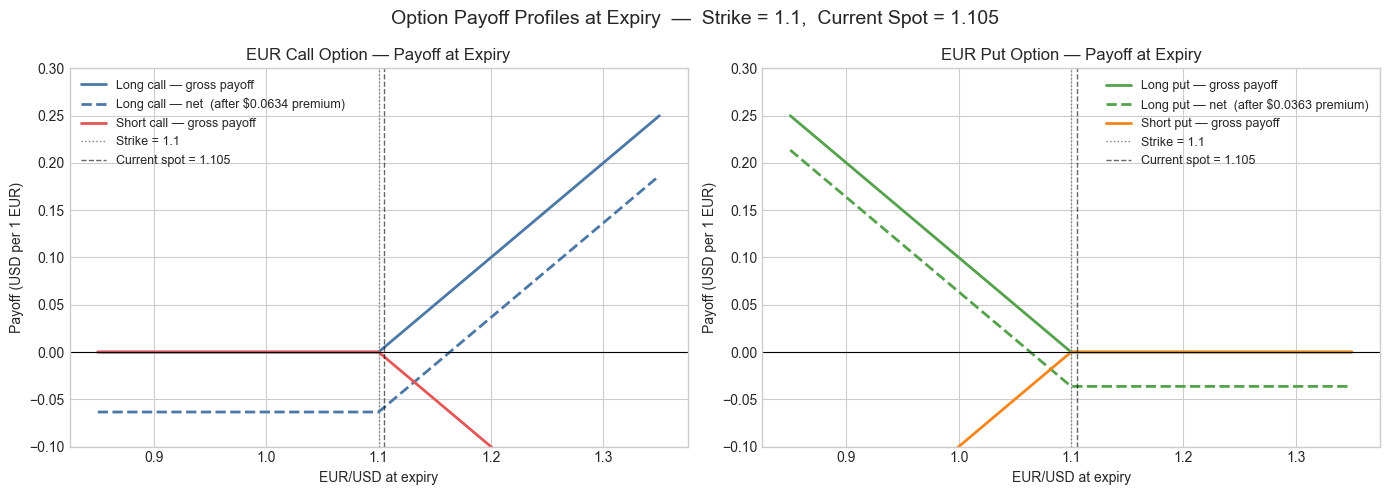

In [13]:

# ── Option payoff at expiry (the "hockey stick" diagrams) ───────────────────
spot_range_payoff = np.linspace(0.85, 1.35, 300)
K_atm = 1.10

call_premium_atm = garman_kohlhagen_price(spot, K_atm, 1.0, domestic_rate, foreign_rate, volatility, "call")
put_premium_atm  = garman_kohlhagen_price(spot, K_atm, 1.0, domestic_rate, foreign_rate, volatility, "put")

long_call_gross = np.maximum(spot_range_payoff - K_atm, 0)
long_put_gross  = np.maximum(K_atm - spot_range_payoff, 0)
long_call_net   = long_call_gross - call_premium_atm
long_put_net    = long_put_gross  - put_premium_atm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: call payoffs ───────────────────────────────────────────────────────
axes[0].plot(spot_range_payoff, long_call_gross, linewidth=2, color="#4C78A8",
             label="Long call — gross payoff")
axes[0].plot(spot_range_payoff, long_call_net,   linewidth=2, linestyle="--", color="#4C78A8",
             label=f"Long call — net  (after ${call_premium_atm:.4f} premium)")
axes[0].plot(spot_range_payoff, -long_call_gross, linewidth=2, color="#E45756",
             label="Short call — gross payoff")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(K_atm, color="gray", linestyle=":", linewidth=1, label=f"Strike = {K_atm}")
axes[0].axvline(spot,  color="black", linestyle="--", linewidth=1, alpha=0.6, label=f"Current spot = {spot}")
axes[0].set_title("EUR Call Option — Payoff at Expiry")
axes[0].set_xlabel("EUR/USD at expiry")
axes[0].set_ylabel("Payoff (USD per 1 EUR)")
axes[0].legend(fontsize=9)
axes[0].set_ylim(-0.10, 0.30)

# ── Right: put payoffs ───────────────────────────────────────────────────────
axes[1].plot(spot_range_payoff, long_put_gross, linewidth=2, color="#54A24B",
             label="Long put — gross payoff")
axes[1].plot(spot_range_payoff, long_put_net,   linewidth=2, linestyle="--", color="#54A24B",
             label=f"Long put — net  (after ${put_premium_atm:.4f} premium)")
axes[1].plot(spot_range_payoff, -long_put_gross, linewidth=2, color="#F58518",
             label="Short put — gross payoff")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(K_atm, color="gray", linestyle=":", linewidth=1, label=f"Strike = {K_atm}")
axes[1].axvline(spot,  color="black", linestyle="--", linewidth=1, alpha=0.6, label=f"Current spot = {spot}")
axes[1].set_title("EUR Put Option — Payoff at Expiry")
axes[1].set_xlabel("EUR/USD at expiry")
axes[1].set_ylabel("Payoff (USD per 1 EUR)")
axes[1].legend(fontsize=9)
axes[1].set_ylim(-0.10, 0.30)

fig.suptitle(f"Option Payoff Profiles at Expiry  —  Strike = {K_atm},  Current Spot = {spot}", fontsize=14)
fig.tight_layout()
plt.show()


### How to read the payoff charts

Both charts show **what happens at expiry** for different values of EUR/USD on that day. The x-axis is the EUR/USD rate at expiry; the y-axis is the profit or loss in USD per 1 EUR of notional.

**Left — Call option:**
- **Long call (solid blue)**: if EUR/USD at expiry is above the strike (1.10), you gain dollar-for-dollar. If it is at or below the strike, the payoff is zero. This is the "hockey stick" — flat on the left, rising on the right.
- **Long call net (dashed blue)**: same as above but after deducting the premium paid. The break-even point is where the dashed line crosses zero — that is strike + premium.
- **Short call (red)**: the mirror image. The option seller collects the premium upfront but faces unlimited loss if spot rises far above the strike.

**Right — Put option:**
- **Long put (solid green)**: you gain if EUR/USD falls below the strike. An exporter who will receive USD can use this to protect EUR revenue if EUR strengthens (i.e., EUR/USD falls).
- **Long put net (dashed green)**: net of premium. Break-even = strike − premium.
- **Short put (orange)**: the seller gains the premium but faces large loss if EUR/USD falls sharply.

**Key insight:** Buying options gives you **limited loss** (just the premium) with **unlimited gain potential** on the favourable side. Selling options gives you the premium upfront but **unlimited risk** on the unfavourable side.

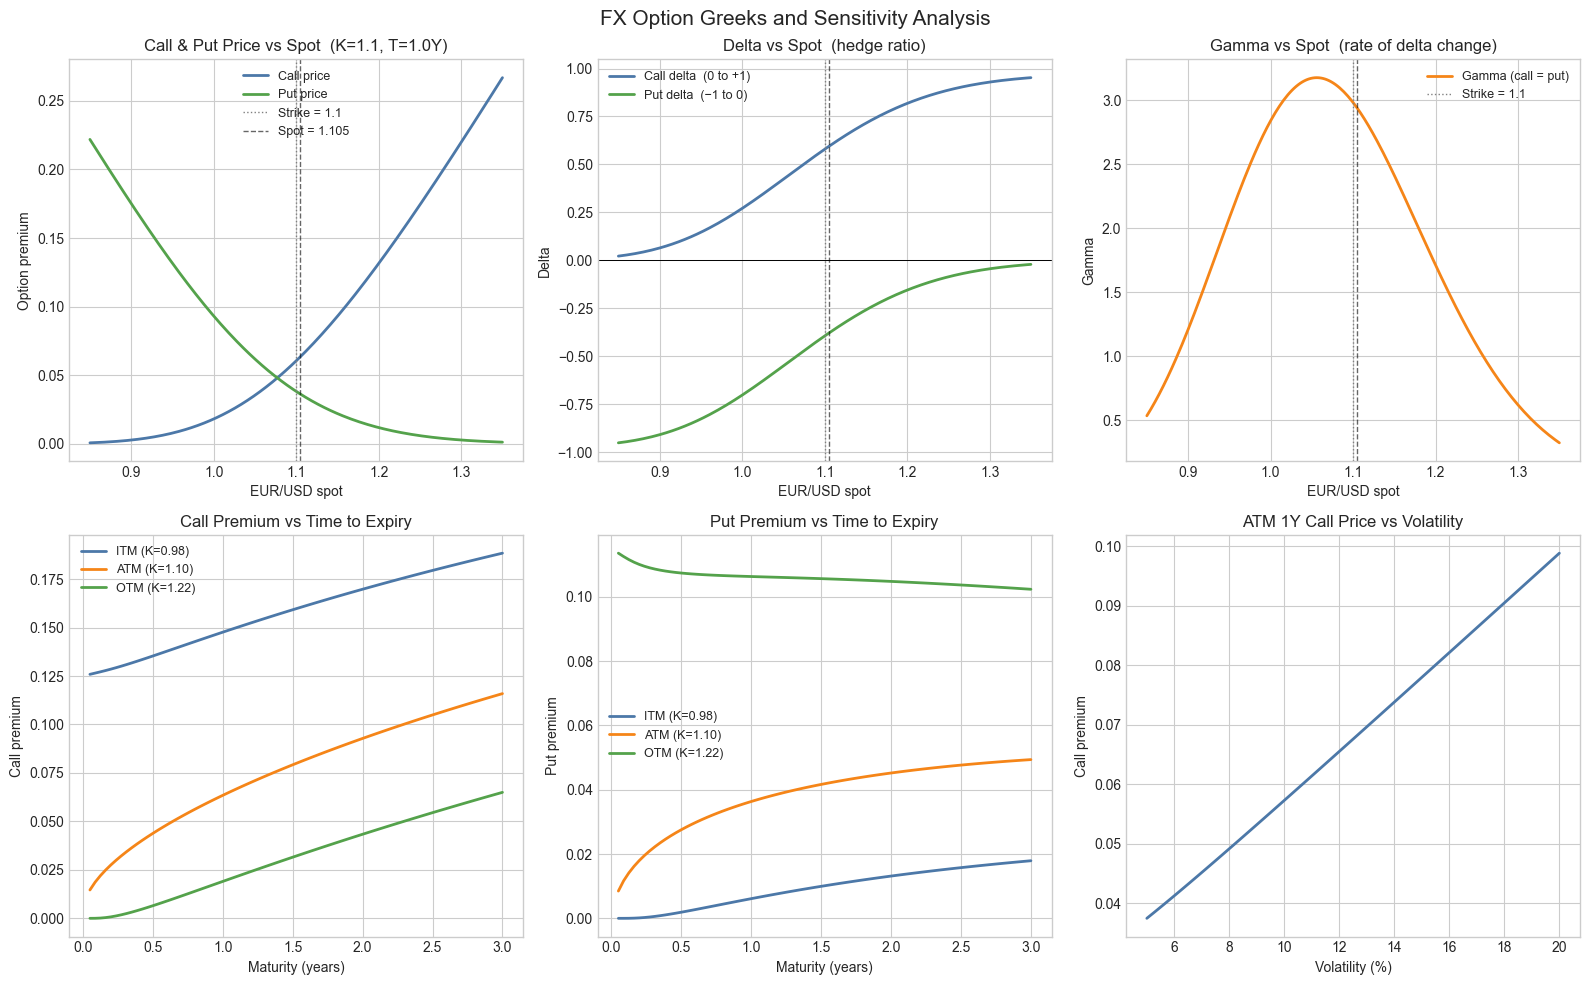

In [14]:

# ── Greeks: Delta, Gamma, and how option price changes with spot ─────────────
spot_range_g = np.linspace(0.85, 1.35, 200)
K_g  = 1.10
T_g  = 1.0

call_prices_g = [garman_kohlhagen_price(s, K_g, T_g, domestic_rate, foreign_rate, volatility, "call") for s in spot_range_g]
put_prices_g  = [garman_kohlhagen_price(s, K_g, T_g, domestic_rate, foreign_rate, volatility, "put")  for s in spot_range_g]
call_deltas_g = [garman_kohlhagen_delta(s, K_g, T_g, domestic_rate, foreign_rate, volatility, "call") for s in spot_range_g]
put_deltas_g  = [garman_kohlhagen_delta(s, K_g, T_g, domestic_rate, foreign_rate, volatility, "put")  for s in spot_range_g]

h_bump = 0.0001
gammas_g = [
    (garman_kohlhagen_price(s + h_bump, K_g, T_g, domestic_rate, foreign_rate, volatility, "call")
     - 2 * garman_kohlhagen_price(s, K_g, T_g, domestic_rate, foreign_rate, volatility, "call")
     + garman_kohlhagen_price(s - h_bump, K_g, T_g, domestic_rate, foreign_rate, volatility, "call")) / h_bump ** 2
    for s in spot_range_g
]

# ── Maturity effect ──────────────────────────────────────────────────────────
maturity_range = np.linspace(0.05, 3.0, 80)
strikes_mat    = [0.98, 1.10, 1.22]
mat_labels     = ["ITM (K=0.98)", "ATM (K=1.10)", "OTM (K=1.22)"]
mat_colors     = ["#4C78A8", "#F58518", "#54A24B"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1 — Greeks
axes[0, 0].plot(spot_range_g, call_prices_g, linewidth=2, color="#4C78A8", label="Call price")
axes[0, 0].plot(spot_range_g, put_prices_g,  linewidth=2, color="#54A24B", label="Put price")
axes[0, 0].axvline(K_g,  color="gray",  linestyle=":", linewidth=1, label=f"Strike = {K_g}")
axes[0, 0].axvline(spot, color="black", linestyle="--", linewidth=1, alpha=0.6, label=f"Spot = {spot}")
axes[0, 0].set_title(f"Call & Put Price vs Spot  (K={K_g}, T={T_g}Y)")
axes[0, 0].set_xlabel("EUR/USD spot")
axes[0, 0].set_ylabel("Option premium")
axes[0, 0].legend(fontsize=9)

axes[0, 1].plot(spot_range_g, call_deltas_g, linewidth=2, color="#4C78A8", label="Call delta  (0 to +1)")
axes[0, 1].plot(spot_range_g, put_deltas_g,  linewidth=2, color="#54A24B", label="Put delta  (−1 to 0)")
axes[0, 1].axhline(0, color="black", linewidth=0.7)
axes[0, 1].axvline(K_g,  color="gray",  linestyle=":", linewidth=1)
axes[0, 1].axvline(spot, color="black", linestyle="--", linewidth=1, alpha=0.6)
axes[0, 1].set_title("Delta vs Spot  (hedge ratio)")
axes[0, 1].set_xlabel("EUR/USD spot")
axes[0, 1].set_ylabel("Delta")
axes[0, 1].legend(fontsize=9)

axes[0, 2].plot(spot_range_g, gammas_g, linewidth=2, color="#F58518", label="Gamma (call = put)")
axes[0, 2].axvline(K_g,  color="gray",  linestyle=":", linewidth=1, label=f"Strike = {K_g}")
axes[0, 2].axvline(spot, color="black", linestyle="--", linewidth=1, alpha=0.6)
axes[0, 2].set_title("Gamma vs Spot  (rate of delta change)")
axes[0, 2].set_xlabel("EUR/USD spot")
axes[0, 2].set_ylabel("Gamma")
axes[0, 2].legend(fontsize=9)

# Row 2 — Maturity effect
for k_val, lbl, col in zip(strikes_mat, mat_labels, mat_colors):
    call_vs_mat = [garman_kohlhagen_price(spot, k_val, T, domestic_rate, foreign_rate, volatility, "call") for T in maturity_range]
    put_vs_mat  = [garman_kohlhagen_price(spot, k_val, T, domestic_rate, foreign_rate, volatility, "put")  for T in maturity_range]
    axes[1, 0].plot(maturity_range, call_vs_mat, linewidth=2, color=col, label=lbl)
    axes[1, 1].plot(maturity_range, put_vs_mat,  linewidth=2, color=col, label=lbl)

axes[1, 0].set_title("Call Premium vs Time to Expiry")
axes[1, 0].set_xlabel("Maturity (years)")
axes[1, 0].set_ylabel("Call premium")
axes[1, 0].legend(fontsize=9)

axes[1, 1].set_title("Put Premium vs Time to Expiry")
axes[1, 1].set_xlabel("Maturity (years)")
axes[1, 1].set_ylabel("Put premium")
axes[1, 1].legend(fontsize=9)

# Vol sensitivity (reuse computed values)
axes[1, 2].plot(100 * vol_grid, vol_sensitivity, linewidth=2, color="#4C78A8")
axes[1, 2].set_title("ATM 1Y Call Price vs Volatility")
axes[1, 2].set_xlabel("Volatility (%)")
axes[1, 2].set_ylabel("Call premium")

fig.suptitle("FX Option Greeks and Sensitivity Analysis", fontsize=15)
fig.tight_layout()
plt.show()


### How to read the Greeks and sensitivity charts

**Top row — Greeks (how option value changes with spot):**

| Panel | What to look for |
|---|---|
| **Call & Put price vs Spot** | Both curves rise as spot moves in the option's favour. Call rises steeply when spot moves above strike; put rises steeply when spot falls below strike. The curves are smooth, not hockey-sticks, because you are viewing the *live* option value before expiry (which includes time value). |
| **Delta vs Spot** | Call delta runs from near 0 (deep OTM) to near +1 (deep ITM). Put delta runs from near −1 (deep ITM) to near 0 (deep OTM). At the strike, both are approximately ±0.50. Delta = the fraction of 1 EUR you need to buy/sell to hedge the option. |
| **Gamma vs Spot** | The bell-shaped curve peaks at the strike. Gamma is highest near ATM because that is where delta is most sensitive to spot moves. High gamma means the hedge ratio changes fast — so you need to rebalance more frequently. |

**Bottom row — How premium grows with time and volatility:**

| Panel | Key insight |
|---|---|
| **Call premium vs maturity** | All three lines rise with time. OTM options (strike 1.22) start near zero and grow slowly; ITM options (strike 0.98) start high and grow more steadily. Longer time = more uncertainty = higher premium. |
| **Put premium vs maturity** | Same pattern. ITM puts are expensive even for short maturities. |
| **Call premium vs volatility** | A straight-line-like relationship: doubling vol roughly doubles the premium. This is why implied vol is the key pricing variable — a 1% change in vol can meaningfully change the cost of a hedge. |

In [5]:
strikes = np.array([1.02, 1.06, 1.10, 1.14, 1.18])
option_maturities = np.array([0.25, 0.5, 1.0])
option_rows = []
for maturity in option_maturities:
    maturity_vol = float(np.interp(maturity, vol_surface_df["maturity_years"], vol_surface_df["atm_implied_vol"]))
    for strike in strikes:
        option_rows.append(
            {
                "maturity_years": maturity,
                "strike": strike,
                "volatility": maturity_vol,
                "call_price": garman_kohlhagen_price(spot, strike, maturity, domestic_rate, foreign_rate, maturity_vol, "call"),
                "put_price": garman_kohlhagen_price(spot, strike, maturity, domestic_rate, foreign_rate, maturity_vol, "put"),
                "call_delta": garman_kohlhagen_delta(spot, strike, maturity, domestic_rate, foreign_rate, maturity_vol, "call"),
            }
        )

option_df = pd.DataFrame(option_rows)
option_df

,maturity_years,strike,volatility,call_price,put_price,call_delta
0,0.250000,1.020000,0.104000,0.090888,0.001155,0.945762
1,0.250000,1.060000,0.104000,0.055803,0.005593,0.817373
2,0.250000,1.100000,0.104000,0.028399,0.017712,0.580861
3,0.250000,1.140000,0.104000,0.011457,0.040293,0.316069
4,0.250000,1.180000,0.104000,0.003566,0.071924,0.127137
5,0.500000,1.020000,0.109000,0.099113,0.004741,0.875588
6,0.500000,1.060000,0.109000,0.067501,0.012182,0.752224
7,0.500000,1.100000,0.109000,0.042028,0.025759,0.584413
8,0.500000,1.140000,0.109000,0.023683,0.046466,0.403633
9,0.500000,1.180000,0.109000,0.012010,0.073844,0.245783


### How to read the option pricing table

The table prices EUR/USD calls and puts across three maturities (3M, 6M, 1Y) and five strikes (1.02 to 1.18). Here is how to interpret the key columns:

| Column | Meaning |
|---|---|
| `maturity_years` | Time until expiry |
| `strike` | The agreed exchange rate in the contract |
| `volatility` | The ATM implied vol used for this maturity — taken from the vol surface above |
| `call_price` | Premium in USD per 1 EUR of notional — what you pay to buy the right to buy EUR at the strike |
| `put_price` | Premium in USD per 1 EUR of notional — what you pay to buy the right to sell EUR at the strike |
| `call_delta` | How much the call price moves for a $1 move in spot — also your hedge ratio |

**Patterns to notice:**
- **Call prices fall as strike rises**: a 1.02 call is deep in-the-money (expensive); a 1.18 call is out-of-the-money (cheap)
- **Put prices rise as strike rises**: a 1.02 put is deep out-of-the-money (cheap); a 1.18 put is in-the-money (expensive)
- **Longer maturity = higher premiums**: more time = more uncertainty = more valuable optionality
- **Call delta near 1.0** for low strikes (deep ITM): the option behaves almost like owning the EUR outright
- **Call delta near 0.0** for high strikes (deep OTM): the option is unlikely to pay off, so spot moves barely change its value

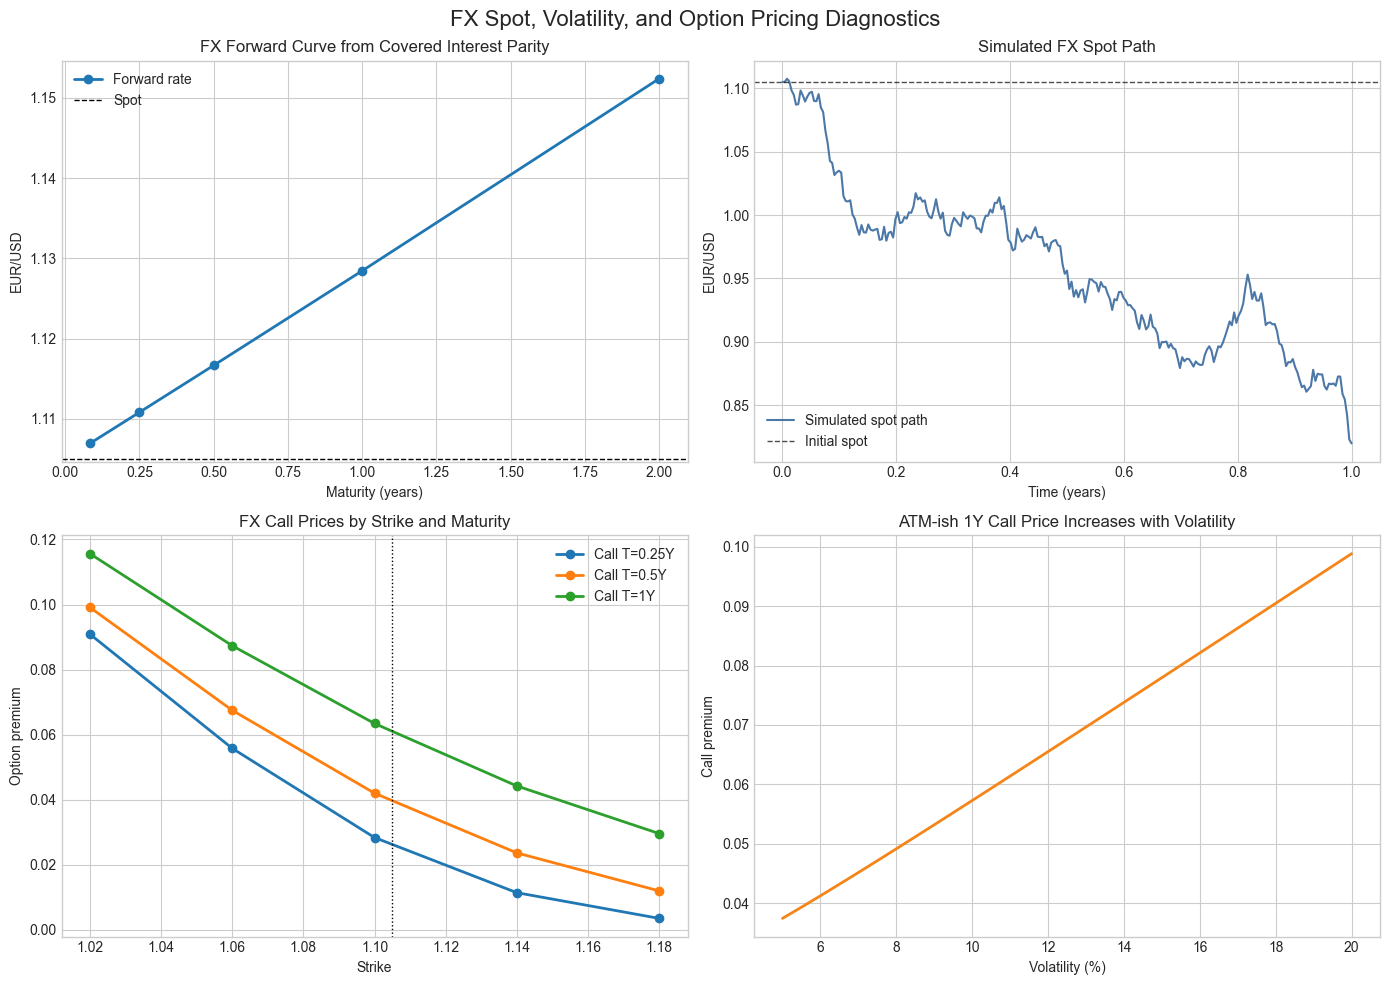

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(forward_table["maturity_years"], forward_table["forward_rate"], marker="o", linewidth=2, label="Forward rate")
axes[0, 0].axhline(spot, color="black", linestyle="--", linewidth=1, label="Spot")
axes[0, 0].set_title("FX Forward Curve from Covered Interest Parity")
axes[0, 0].set_xlabel("Maturity (years)")
axes[0, 0].set_ylabel("EUR/USD")
axes[0, 0].legend()

axes[0, 1].plot(fx_path["time_years"], fx_path["spot"], color="#4C78A8", linewidth=1.5, label="Simulated spot path")
axes[0, 1].axhline(spot, color="black", linestyle="--", linewidth=1, alpha=0.7, label="Initial spot")
axes[0, 1].set_title("Simulated FX Spot Path")
axes[0, 1].set_xlabel("Time (years)")
axes[0, 1].set_ylabel("EUR/USD")
axes[0, 1].legend()

for maturity in option_maturities:
    subset = option_df[option_df["maturity_years"] == maturity]
    axes[1, 0].plot(subset["strike"], subset["call_price"], marker="o", linewidth=2, label=f"Call T={maturity:g}Y")
axes[1, 0].axvline(spot, color="black", linestyle=":", linewidth=1)
axes[1, 0].set_title("FX Call Prices by Strike and Maturity")
axes[1, 0].set_xlabel("Strike")
axes[1, 0].set_ylabel("Option premium")
axes[1, 0].legend()

vol_grid = np.linspace(0.05, 0.20, 50)
vol_sensitivity = [garman_kohlhagen_price(spot, 1.10, 1.0, domestic_rate, foreign_rate, sigma, "call") for sigma in vol_grid]
axes[1, 1].plot(100 * vol_grid, vol_sensitivity, linewidth=2, color="#F58518")
axes[1, 1].set_title("ATM-ish 1Y Call Price Increases with Volatility")
axes[1, 1].set_xlabel("Volatility (%)")
axes[1, 1].set_ylabel("Call premium")

fig.suptitle("FX Spot, Volatility, and Option Pricing Diagnostics", fontsize=16)
fig.tight_layout()
plt.show()

### How to read the 4-panel chart

**Top left — FX Forward Curve from Covered Interest Parity**
- The solid line shows forward rates at each maturity; the dashed line marks today's spot.
- The forward curves upward when USD rates > EUR rates (USD interest rate advantage pushes forward above spot).
- Practical use: if you need to agree a rate today for a payment 1 year from now, this is the fair rate.

**Top right — Simulated FX Spot Path**
- A single simulated year of EUR/USD prices using geometric Brownian motion.
- The path fluctuates randomly around the initial spot because spot follows a log-normal process with drift (rate differential) and diffusion (volatility).
- Practical use: visualises how uncertain the exchange rate is over 1 year — an importer who does not hedge faces any of these possible outcomes.

**Bottom left — FX Call Prices by Strike and Maturity**
- Three curves, one for each maturity (3M, 6M, 1Y). Each point is the call premium at that strike.
- All curves slope downward: higher strike = less likely to be in-the-money = cheaper call.
- Longer-maturity curves sit higher because more time means more chance of large moves.
- The vertical dotted line marks the current spot (1.1050).

**Bottom right — ATM Call Price vs Volatility**
- A single line showing how the 1Y ATM call price changes as vol varies from 5% to 20%.
- It rises almost linearly with vol — a key rule: **options are bets on volatility**.
- Practical use: if a risk manager says "vol is cheap right now", this chart shows exactly how much lower the premium is at lower vol levels.

## 4. SABR Model for FX Volatility Smiles

### Why SABR is needed in practice
Flat-volatility models (single volatility for all strikes) are useful for intuition but usually fail in production quoting. In FX, implied volatility depends on strike and maturity, and that dependency directly changes premiums, hedge ratios, and risk reports.

### Practical reasons with concrete examples
1. **Market smiles and skews are real, not noise.**
   Practical example: A bank quoting EUR/USD options sees 1Y implied vol around 11% near ATM but 12.5% to 13% for far OTM downside strikes. A flat 11% model underprices those strikes and loses money if the desk sells too cheaply.

2. **Risk-neutral valuation needs strike-specific volatility.**
   Practical example: A corporate buys a 1Y EUR call with strike 1.20 to protect USD costs for imports. Pricing that hedge with ATM vol instead of smile-consistent SABR vol can materially understate the premium and expected hedge budget.

3. **Delta and vega hedging depend on the smile shape.**
   Practical example: Two options with same maturity but different strikes can have different implied vols and therefore different deltas/vegas. A trader hedging both positions with one flat-vol assumption gets persistent hedge slippage.

4. **Consistent interpolation across strikes and maturities is required.**
   Practical example: Sales asks for an off-grid strike and tenor quote, for example 9M at strike 1.17. SABR provides a smooth surface to interpolate a defensible implied vol, instead of ad hoc manual adjustments.

5. **Stress testing and scenario analysis are more realistic.**
   Practical example: In a risk stress where spot falls and skew steepens, SABR-style parameter shifts can capture both level and curvature changes in vol, producing more realistic PnL than a fixed-vol stress.

### SABR dynamics (conceptual)
A common SABR specification models the forward FX rate $F_t$ and its stochastic volatility $\alpha_t$ as:

$$dF_t = \alpha_t F_t^{\beta} dW_t^{(1)}, \qquad d\alpha_t = \nu \alpha_t dW_t^{(2)}, \qquad dW_t^{(1)}dW_t^{(2)} = \rho dt$$

Key parameters:
- **$\alpha$**: volatility level.
- **$\beta$**: elasticity controlling how volatility scales with the forward level.
- **$\rho$**: correlation between forward moves and volatility moves, shaping skew direction.
- **$\nu$**: vol-of-vol controlling smile curvature.

### Practical pricing workflow
1. Start from spot and rates to compute forwards.
2. Calibrate SABR parameters to market implied vols across strikes.
3. Use SABR-implied vol at each strike and maturity.
4. Price vanilla options with Garman-Kohlhagen using those strike-specific vols.

The next cells create synthetic SABR market-like data and plot smile and pricing effects.

In [9]:
def sabr_implied_vol_hagan(forward: float, strike: float, maturity: float, alpha: float, beta: float, rho: float, nu: float) -> float:
    if forward <= 0 or strike <= 0:
        raise ValueError("Forward and strike must be strictly positive.")
    if maturity <= 0:
        return 0.0

    one_minus_beta = 1.0 - beta
    fk_beta = (forward * strike) ** (0.5 * one_minus_beta)
    log_fk = math.log(forward / strike)

    if abs(log_fk) < 1e-12:
        term1 = alpha / (forward ** one_minus_beta)
        term2 = (
            ((one_minus_beta ** 2) / 24.0) * (alpha ** 2) / (forward ** (2.0 * one_minus_beta))
            + (rho * beta * nu * alpha) / (4.0 * (forward ** one_minus_beta))
            + ((2.0 - 3.0 * rho ** 2) * nu ** 2 / 24.0)
        ) * maturity
        return float(term1 * (1.0 + term2))

    z = (nu / alpha) * fk_beta * log_fk
    x_z = math.log((math.sqrt(1.0 - 2.0 * rho * z + z ** 2) + z - rho) / (1.0 - rho))

    log_fk_sq = log_fk ** 2
    log_fk_4 = log_fk_sq ** 2
    denominator = fk_beta * (1.0 + (one_minus_beta ** 2 / 24.0) * log_fk_sq + (one_minus_beta ** 4 / 1920.0) * log_fk_4)

    time_adjustment = (
        ((one_minus_beta ** 2) / 24.0) * (alpha ** 2) / ((forward * strike) ** one_minus_beta)
        + (rho * beta * nu * alpha) / (4.0 * fk_beta)
        + ((2.0 - 3.0 * rho ** 2) * nu ** 2 / 24.0)
    ) * maturity

    return float((alpha / denominator) * (z / x_z) * (1.0 + time_adjustment))


sabr_param_table = pd.DataFrame(
    {
        "maturity_years": [0.25, 0.5, 1.0, 2.0],
        "alpha": [0.105, 0.108, 0.112, 0.118],
        "beta": [0.75, 0.75, 0.75, 0.75],
        "rho": [-0.25, -0.22, -0.20, -0.18],
        "nu": [0.55, 0.50, 0.45, 0.40],
    }
)

sabr_strikes = np.linspace(0.95, 1.25, 17)
sabr_rows = []
for _, params in sabr_param_table.iterrows():
    maturity = float(params["maturity_years"])
    forward = fx_forward_rate(spot, domestic_rate, foreign_rate, maturity)
    alpha = float(params["alpha"])
    beta = float(params["beta"])
    rho = float(params["rho"])
    nu = float(params["nu"])

    for strike in sabr_strikes:
        sabr_vol = sabr_implied_vol_hagan(forward, strike, maturity, alpha, beta, rho, nu)
        noisy_market_vol = max(0.01, sabr_vol + RNG.normal(0.0, 0.0015))
        sabr_rows.append(
            {
                "maturity_years": maturity,
                "forward": forward,
                "strike": strike,
                "sabr_implied_vol": sabr_vol,
                "synthetic_market_vol": noisy_market_vol,
                "call_price_sabr": garman_kohlhagen_price(spot, strike, maturity, domestic_rate, foreign_rate, sabr_vol, "call"),
                "call_price_flat_vol": garman_kohlhagen_price(spot, strike, maturity, domestic_rate, foreign_rate, float(np.interp(maturity, vol_surface_df["maturity_years"], vol_surface_df["atm_implied_vol"])), "call"),
            }
        )

sabr_df = pd.DataFrame(sabr_rows)
sabr_df.head(12)

,maturity_years,forward,strike,sabr_implied_vol,synthetic_market_vol,call_price_sabr,call_price_flat_vol
0,0.250000,1.110817,0.950000,0.123205,0.122049,0.159009,0.158918
1,0.250000,1.110817,0.968750,0.120117,0.120983,0.140612,0.140442
2,0.250000,1.110817,0.987500,0.117179,0.119466,0.122349,0.122065
3,0.250000,1.110817,1.006250,0.114405,0.113935,0.104338,0.103918
4,0.250000,1.110817,1.025000,0.111813,0.110911,0.086778,0.086237
5,0.250000,1.110817,1.043750,0.109421,0.109709,0.069967,0.069385
6,0.250000,1.110817,1.062500,0.107249,0.107246,0.054308,0.053820
7,0.250000,1.110817,1.081250,0.105315,0.103825,0.040275,0.040027
8,0.250000,1.110817,1.100000,0.103639,0.104330,0.028322,0.028399
9,0.250000,1.110817,1.118750,0.102235,0.105258,0.018758,0.019142


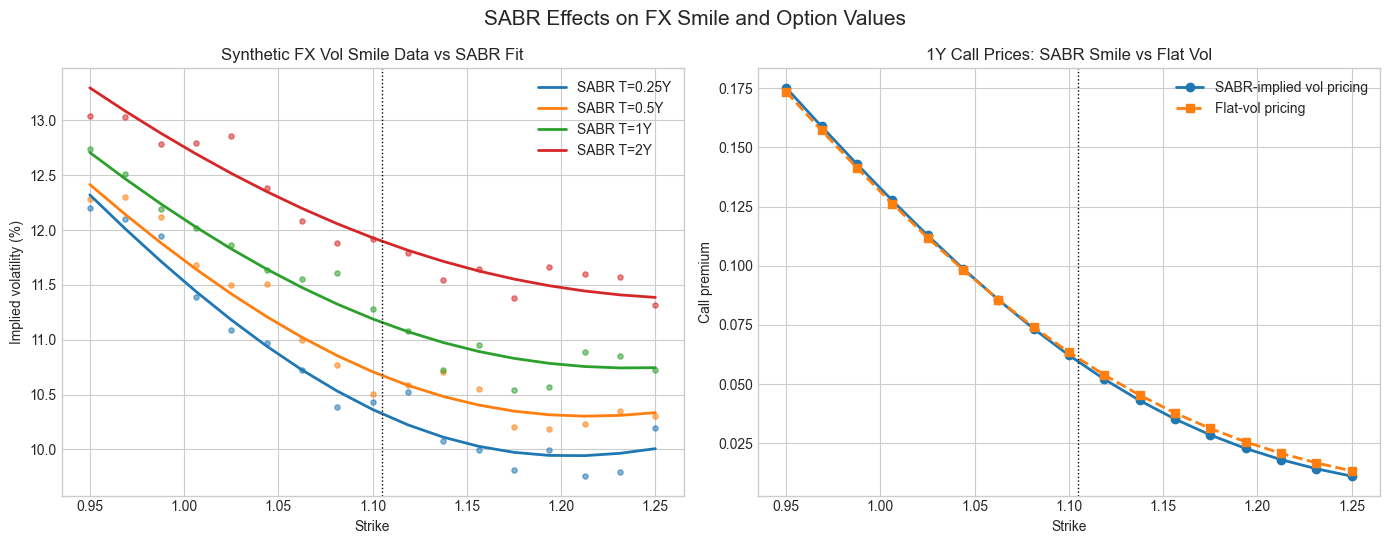

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for maturity in sabr_param_table["maturity_years"]:
    maturity_slice = sabr_df[sabr_df["maturity_years"] == maturity]
    axes[0].plot(maturity_slice["strike"], 100 * maturity_slice["sabr_implied_vol"], linewidth=2, label=f"SABR T={maturity:g}Y")
    axes[0].scatter(maturity_slice["strike"], 100 * maturity_slice["synthetic_market_vol"], s=14, alpha=0.55)
axes[0].axvline(spot, color="black", linestyle=":", linewidth=1)
axes[0].set_title("Synthetic FX Vol Smile Data vs SABR Fit")
axes[0].set_xlabel("Strike")
axes[0].set_ylabel("Implied volatility (%)")
axes[0].legend()

maturity_focus = 1.0
focus_slice = sabr_df[sabr_df["maturity_years"] == maturity_focus]
axes[1].plot(focus_slice["strike"], focus_slice["call_price_sabr"], marker="o", linewidth=2, label="SABR-implied vol pricing")
axes[1].plot(focus_slice["strike"], focus_slice["call_price_flat_vol"], marker="s", linestyle="--", linewidth=2, label="Flat-vol pricing")
axes[1].axvline(spot, color="black", linestyle=":", linewidth=1)
axes[1].set_title("1Y Call Prices: SABR Smile vs Flat Vol")
axes[1].set_xlabel("Strike")
axes[1].set_ylabel("Call premium")
axes[1].legend()

fig.suptitle("SABR Effects on FX Smile and Option Values", fontsize=15)
fig.tight_layout()
plt.show()

### How to read the SABR smile charts

**Left — Vol Smile: SABR Model vs Synthetic Market Data**
- Four curves, one per maturity. Each curve shows implied volatility plotted against the EUR/USD strike.
- The dots are synthetic "market quotes" with small random noise added to the SABR output — simulating real quoted vols from a broker screen.
- **Shape of the smile**: most curves are not flat — vol is slightly higher at low strikes (downside tail) and at high strikes (upside tail) compared to ATM. The asymmetry (skew) means puts on the downside are more expensive relative to ATM than puts on the upside.
- The vertical dotted line marks current spot. The vol at that point is the ATM vol.
- **How the SABR line tracks the dots**: good model calibration means the smooth curve passes close to all the noisy market quotes.

**Right — 1Y Call Prices: SABR Smile vs Flat Vol Pricing**
- SABR pricing (solid circles) vs flat ATM-vol pricing (dashed squares) for the same 1Y call across all strikes.
- **Near ATM**: the two lines are close — a flat vol is a reasonable approximation near ATM.
- **Far from ATM (especially low strikes, ITM calls)**: the SABR line diverges. This is the pricing error you incur by ignoring the smile. The next chart quantifies this in dollar terms on a real-size notional.

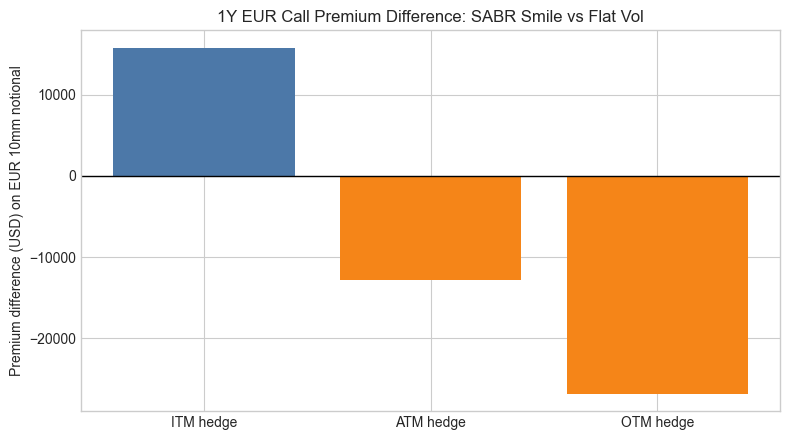

In [11]:
example_notional_eur = 10_000_000
example_strikes = [0.98, 1.10, 1.22]
example_labels = ["ITM hedge", "ATM hedge", "OTM hedge"]
example_rows = []

for label, strike in zip(example_labels, example_strikes):
    row = sabr_df[(np.isclose(sabr_df["maturity_years"], 1.0)) & (np.isclose(sabr_df["strike"], strike, atol=1e-9))]
    if row.empty:
        row = sabr_df[(np.isclose(sabr_df["maturity_years"], 1.0))].iloc[(sabr_df[(np.isclose(sabr_df["maturity_years"], 1.0))]["strike"] - strike).abs().argsort().iloc[:1]]
    row = row.iloc[0]

    premium_sabr = row["call_price_sabr"] * example_notional_eur
    premium_flat = row["call_price_flat_vol"] * example_notional_eur

    example_rows.append(
        {
            "case": label,
            "strike": float(row["strike"]),
            "sabr_vol_pct": 100 * float(row["sabr_implied_vol"]),
            "flat_vol_pct": 100 * float(np.interp(1.0, vol_surface_df["maturity_years"], vol_surface_df["atm_implied_vol"])),
            "premium_sabr_usd": premium_sabr,
            "premium_flat_usd": premium_flat,
            "premium_difference_usd": premium_sabr - premium_flat,
        }
    )

practical_examples_df = pd.DataFrame(example_rows)
practical_examples_df

fig, ax = plt.subplots(figsize=(8, 4.5))
bar_colors = ["#4C78A8" if value >= 0 else "#F58518" for value in practical_examples_df["premium_difference_usd"]]
ax.bar(practical_examples_df["case"], practical_examples_df["premium_difference_usd"], color=bar_colors)
ax.axhline(0.0, color="black", linewidth=1)
ax.set_title("1Y EUR Call Premium Difference: SABR Smile vs Flat Vol")
ax.set_ylabel("Premium difference (USD) on EUR 10mm notional")
plt.tight_layout()
plt.show()

## 5. Practical Use Cases

### 1. Corporate hedging (importer)
- Situation: a US company must pay EUR 25 million in 9 months.
- Risk: EUR/USD rises and increases USD payment cost.
- Typical trade: buy EUR forward or buy a EUR call option.
- Why this notebook matters: Sections 1 and 3 show how to estimate fair forward and option premium.

### 2. Corporate hedging (exporter)
- Situation: a Eurozone exporter will receive USD in 6 months.
- Risk: EUR/USD falls and reduces EUR revenue after conversion.
- Typical trade: sell USD forward or buy a EUR put/USD call style hedge.
- Why this notebook matters: strike selection and premium trade-off are visible in the option tables.

### 3. Bank market making and sales quoting
- Situation: a client asks for off-grid strikes and tenors during the day.
- Risk: inconsistent or stale vol assumptions produce bad quotes.
- Typical approach: calibrate smile parameters, then quote from a smooth vol surface.
- Why this notebook matters: the SABR section shows why smile-consistent vols are preferred over flat vol.

### 4. Trading desk risk management
- Situation: desk holds a portfolio of calls and puts across strikes.
- Risk: spot and skew moves can create nonlinear PnL.
- Typical approach: monitor delta/vega and run stress scenarios under smile dynamics.
- Why this notebook matters: SABR-vs-flat examples show how model choice changes premium and risk.

### 5. Budgeting and planning for treasury teams
- Situation: treasury needs a realistic hedge budget for the quarter.
- Risk: using ATM vol for all strikes underestimates hedging cost in skewed markets.
- Typical approach: scenario-based premium ranges using smile-consistent vols.
- Why this notebook matters: practical premium-difference chart quantifies potential under/over-estimation.

## 6. Risk: Value at Risk (VaR)

### 6.1 What is VaR?

**Value at Risk (VaR)** answers one specific question: *"What is the maximum loss I should expect to see on X% of trading days?"*

It is expressed as a positive loss number. For example:

> **95% one-day VaR = $85,000** means: on 95% of trading days, your loss will be *less* than $85,000. On the other 5% of days (about 1 in 20), you could lose more.

VaR is not a worst-case scenario — it is a **statistical threshold**. Losses can still exceed VaR on bad days.

### 6.2 The three VaR methods

| Method | How it works | Pros | Cons |
|---|---|---|---|
| **Historical VaR** | Sort actual past PnL; find the worst X% outcome | No distribution assumption; captures real market behaviour | Depends on the historical window; past may not reflect future |
| **Parametric (Normal) VaR** | Assume PnL is normally distributed; use mean and std dev | Simple to calculate | Underestimates tail losses; real returns have fat tails |
| **Monte Carlo VaR** | Simulate thousands of random scenarios; find X% worst outcome | Flexible; can model complex payoffs | Depends on the assumed model and its parameters |

### 6.3 Expected Shortfall (ES) — going beyond VaR

**Expected Shortfall** (also called CVaR or Average VaR) asks: *"When I do have a bad day (beyond VaR), how bad is it on average?"*

> **99% one-day ES = $160,000** means: on the 1% worst days, the average loss is $160,000.

ES is considered a better risk measure than VaR because:
- It captures the severity of losses in the tail, not just a threshold
- It penalizes strategies that have small probability but catastrophic losses
- Regulators (Basel III/IV) now prefer ES over VaR for bank capital calculations

### 6.4 Practical FX risk example
In this section we estimate one-day VaR and ES for a long EUR position worth €8 million, using the simulated EUR/USD path from Section 2. The PnL is the daily change in EUR spot value, converted to USD.

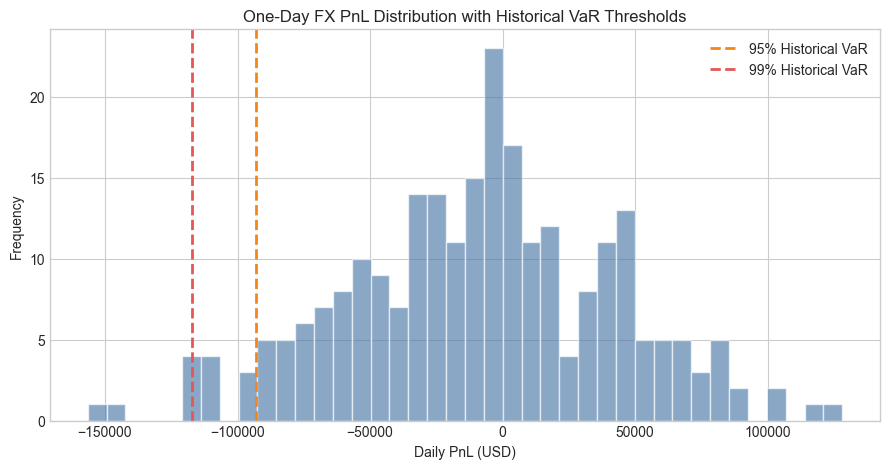

In [12]:
var_notional_eur = 8_000_000

# One-day USD PnL from EUR exposure: long EUR position valued in USD.
fx_pnl = var_notional_eur * fx_path["spot"].diff().dropna()

confidence_levels = [0.95, 0.99]
mu = float(fx_pnl.mean())
sigma = float(fx_pnl.std(ddof=1))
mc_scenarios = 100_000
mc_pnl = RNG.normal(loc=mu, scale=sigma, size=mc_scenarios)

var_rows = []
for cl in confidence_levels:
    alpha = 1.0 - cl

    # VaR is reported as a positive loss number.
    hist_quantile = float(np.quantile(fx_pnl, alpha))
    param_quantile = float(mu + sigma * norm.ppf(alpha))
    mc_quantile = float(np.quantile(mc_pnl, alpha))

    hist_var = -hist_quantile
    param_var = -param_quantile
    mc_var = -mc_quantile

    hist_es = -float(fx_pnl[fx_pnl <= hist_quantile].mean())
    mc_es = -float(mc_pnl[mc_pnl <= mc_quantile].mean())

    var_rows.append(
        {
            "confidence_level": cl,
            "historical_var_usd": hist_var,
            "parametric_var_usd": param_var,
            "monte_carlo_var_usd": mc_var,
            "historical_es_usd": hist_es,
            "monte_carlo_es_usd": mc_es,
        }
    )

var_df = pd.DataFrame(var_rows)
var_df

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(fx_pnl, bins=40, alpha=0.65, color="#4C78A8", edgecolor="white")
ax.axvline(-var_df.loc[var_df["confidence_level"] == 0.95, "historical_var_usd"].iloc[0], color="#F58518", linestyle="--", linewidth=2, label="95% Historical VaR")
ax.axvline(-var_df.loc[var_df["confidence_level"] == 0.99, "historical_var_usd"].iloc[0], color="#E45756", linestyle="--", linewidth=2, label="99% Historical VaR")
ax.set_title("One-Day FX PnL Distribution with Historical VaR Thresholds")
ax.set_xlabel("Daily PnL (USD)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

### How to read the VaR table and chart

**The VaR table:**

| Column | What it tells you |
|---|---|
| `confidence_level` | 0.95 = 95% confidence; 0.99 = 99% confidence |
| `historical_var_usd` | Worst 5% (or 1%) daily loss actually seen in the simulated path |
| `parametric_var_usd` | Worst daily loss calculated by assuming normal distribution |
| `monte_carlo_var_usd` | Worst daily loss from 100,000 simulated one-day scenarios |
| `historical_es_usd` | Average loss on the days *worse than* the historical VaR threshold |
| `monte_carlo_es_usd` | Average loss from MC simulations beyond the VaR threshold |

**Expected Shortfall > VaR**: always. ES is the average of the tail, while VaR is just the boundary. For risk-aware decision making, ES is more informative.

**Why parametric VaR differs from the others**: the parametric method assumes returns are perfectly normally distributed. Real FX returns have slightly fatter tails, so the parametric method can underestimate tail risk. The historical and Monte Carlo methods capture this better.

**The histogram:**
- Each bar represents how often the daily PnL from the EUR position fell in that range during the simulated year.
- The orange dashed line marks the 95% VaR threshold — losses to the left of this line happened on only 5% of days.
- The red dashed line marks the 99% VaR — losses to the left of this happened on only 1% of days.
- The bulk of days cluster near zero: on most days, an €8M position does not move dramatically.
- **Fat left tail**: the distribution has more extreme losses than a perfect bell curve would predict.

## Main Takeaways

### Core rules to remember

1. **FX rate = price of one currency in another.** EUR/USD = 1.1050 means €1 = $1.1050. Always know which is base and which is quote.

2. **FX forwards are priced by no-arbitrage, not forecasting.** The forward rate is driven by the interest-rate differential between the two currencies. A higher domestic rate pushes the forward above spot (forward premium).

3. **Volatility is the most important input for options.** Higher volatility always increases both call and put premiums. Implied volatility is the market's price of uncertainty.

4. **Options cost a premium but remove the obligation.** Unlike forwards, options let you benefit if the market moves in your favour while protecting against adverse moves. This flexibility has a cost.

5. **Delta tells you the hedge ratio.** A 0.50-delta call means you need to sell €0.50 for every €1 of call notional to hedge the spot exposure. Delta changes as spot moves (that is Gamma).

6. **Flat volatility misprices off-the-money options.** In real FX markets, implied volatility changes with strike (the smile). SABR and similar models capture this to give accurate prices across all strikes.

7. **VaR is a threshold, not a worst case.** A 99% VaR says losses exceed that number 1% of the time. Expected Shortfall (ES) tells you the average loss when VaR is breached — a more complete risk picture.

---

### Beginner checklist — can you answer these?

- [ ] EUR/USD falls from 1.1050 to 1.0950. Did EUR strengthen or weaken? Who benefits: an importer or an exporter of EUR goods?
- [ ] If US interest rates rise and EUR rates stay the same, does the EUR/USD forward rate go up or down relative to spot?
- [ ] You buy a EUR call with strike 1.10. At expiry spot is 1.08. Do you exercise the option? What is your total PnL?
- [ ] Why does a 1Y option cost more than a 3M option on the same strike (all else equal)?
- [ ] What does a call delta of 0.30 tell you about how to hedge the option?
- [ ] If implied vol for a 1.22 strike is higher than for a 1.10 ATM strike, is there a volatility smile or is vol flat?
- [ ] What is the difference between 95% VaR and 95% Expected Shortfall?

---

### Topics to explore next

- **Delta-based strike quoting**: FX option markets quote strikes using delta (25-delta, 10-delta) rather than absolute levels
- **Risk reversals and butterflies**: standard building blocks for constructing a smile from three market quotes
- **Barrier options**: options that activate or cancel if spot crosses a threshold (knock-in, knock-out)
- **SABR calibration**: fitting SABR parameters to live market quotes so the model matches real prices
- **Local volatility and stochastic vol**: more advanced models for exotic option pricing
- **FX options portfolio Greeks**: running a multi-strike, multi-maturity book and managing aggregate delta/gamma/vega